# Custom XGBoost model implemantation

<br>  The goal of this work was to implement a custom machine-learning model based on gradient boosting principles. Gradient boosting is an ensemble method that builds a strong predictive model by combining many weak learners—typically decision trees. 
<br> The model operates iteratively. It begins with a simple initial prediction and then repeatedly adds new trees that correct the errors (residuals) made by the previous ones. After each iteration, the model calculates the residuals, which represent how far the current predictions are from the true values. A new tree is then trained specifically to predict these residuals. By doing so, each tree focuses on what the previous trees failed to learn.
<br> Over many iterations, the model produces a sequence of trees, each improving the overall accuracy. The final prediction is the sum of all tree outputs, scaled by a learning rate that controls how much each individual tree contributes.

In [233]:
import numpy as np
import pandas as pd
import kagglehub
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, confusion_matrix, auc, roc_curve, f1_score

In [9]:
def load_heart_failure_dataset(path, target_col):
    """Downloads and returns the Heart Failure dataset as a Pandas DataFrame."""

    dataset_id = path

    path = kagglehub.dataset_download(dataset_id)

    csv_path = f"{path}/heart.csv"
    df = pd.read_csv(csv_path)

    # separate features and target
    X = df.drop(columns=[target_col])
    y = df[target_col]

    # encode categorical columns
    for col in X.select_dtypes(include=["object", "category"]).columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))

    return df, X, y

In [10]:
class DecisionTreeRegressor:
    def __init__(self, max_depth=3):
        self.max_depth = max_depth
        self.tree_ = None

    def _variance(self, y):
        return np.var(y)

    def _split(self, X, y, feature_index, threshold):
        left_mask = X[:, feature_index] < threshold
        right_mask = ~left_mask
        return X[left_mask], y[left_mask], X[right_mask], y[right_mask]

    def _best_split(self, X, y):
        best_feat, best_thresh, best_var = None, None, float("inf")
        n_samples, n_features = X.shape

        for feat in range(n_features):
            thresholds = np.unique(X[:, feat])
            for t in thresholds:
                X_left, y_left, X_right, y_right = self._split(X, y, feat, t)
                if len(y_left) == 0 or len(y_right) == 0:
                    continue
                var = (len(y_left)*self._variance(y_left) + len(y_right)*self._variance(y_right)) / len(y)
                if var < best_var:
                    best_feat, best_thresh, best_var = feat, t, var
        return best_feat, best_thresh

    def _build(self, X, y, depth=0):
        if depth == self.max_depth or len(X) == 0:
            return np.mean(y)

        feat, thresh = self._best_split(X, y)
        if feat is None:
            return np.mean(y)

        X_left, y_left, X_right, y_right = self._split(X, y, feat, thresh)
        left_branch = self._build(X_left, y_left, depth + 1)
        right_branch = self._build(X_right, y_right, depth + 1)

        return (feat, thresh, left_branch, right_branch)

    # --- fit & predict ---
    def fit(self, X, y):
        self.tree_ = self._build(X, y)
        return self

    def _predict_one(self, x, tree):
        if not isinstance(tree, tuple):
            return tree
        feat, thresh, left, right = tree

        if x[feat] < thresh:
            return self._predict_one(x, left)
        else:
            return self._predict_one(x, right)

    def predict(self, X):
        return np.array([self._predict_one(x, self.tree_) for x in X])

In [170]:
class MiniXGBoost:
    def __init__(self, n_estimators=5, learning_rate=0.1, max_depth=3, task="regression", scale_pos_weight=1.0):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.task = task
        self.scale_pos_weight = scale_pos_weight
        self.trees = []

    def _sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def fit(self, X, y):
    
        y_pred = np.zeros_like(y, dtype=float)
    
        for i in range(self.n_estimators):
    
            if self.task == "classification":
                y_pred_proba = self._sigmoid(y_pred)
                gradients = y - y_pred_proba
            
                gradients[y == 1] *= self.scale_pos_weight
                
                residuals = gradients
            else:
                residuals = (y - y_pred) * self.sample_weight
    
            tree = DecisionTreeRegressor(max_depth=self.max_depth)
            tree.fit(X, residuals)
    
            update = tree.predict(X)
            y_pred += self.learning_rate * update
            self.trees.append(tree)

    def predict(self, X, as_proba=False):
        y_pred = np.zeros(X.shape[0])
        for tree in self.trees:
            y_pred += self.learning_rate * tree.predict(X)

        if self.task == "classification":
            y_pred = self._sigmoid(y_pred)
            if not as_proba:
                y_pred = (y_pred >= 0.5).astype(int)

        return y_pred


In [12]:
def load_data():
    df, X, y = load_heart_failure_dataset("tan5577/heart-failure-dataset", "HeartDisease")

    return df, X, y

In [148]:
df, X, y = load_data()

In [178]:
X = X[["ChestPainType","MaxHR", "ExerciseAngina", "ST_Slope", "Oldpeak"]]

In [205]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2)

In [206]:
neg = (y == 0).sum()
pos = (y == 1).sum()
spw = neg / pos

In [219]:
model = MiniXGBoost(n_estimators=500, learning_rate=0.1, max_depth=3, task="classification")

In [220]:
model.fit(X_train.values, y_train.values)
y_test_probs = model.predict(X_test.values, as_proba=True)
y_test_labels = model.predict(X_test.values, as_proba=False)

In [221]:
print("Accuracy:", accuracy_score(y_test, y_test_labels))
print("ROC-AUC:", roc_auc_score(y_test, y_test_probs))

Accuracy: 0.8478260869565217
ROC-AUC: 0.9109101868595539


In [222]:
best_f1 = 0
best_t = 0
for t in thresholds:
    f1 = f1_score(y_test, y_test_probs >= t)
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

In [223]:
y_test_labels = (y_test_probs >= best_t).astype(int)

In [224]:
print("Accuracy:", accuracy_score(y_test, y_test_labels))
print("ROC-AUC:", roc_auc_score(y_test, y_test_probs))

Accuracy: 0.8641304347826086
ROC-AUC: 0.9109101868595539


In [225]:

print(classification_report(y_test, (y_test_probs >= best_t)))

              precision    recall  f1-score   support

           0       0.92      0.75      0.83        79
           1       0.83      0.95      0.89       105

    accuracy                           0.86       184
   macro avg       0.88      0.85      0.86       184
weighted avg       0.87      0.86      0.86       184



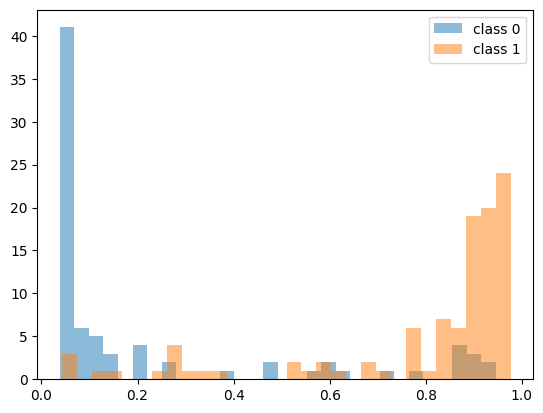

In [226]:
plt.hist(y_test_probs[y_test == 0], bins=30, alpha=0.5, label="class 0")
plt.hist(y_test_probs[y_test == 1], bins=30, alpha=0.5, label="class 1")
plt.legend()
plt.show()

In [227]:
target_names = ["normal", "abnormal"]
def plot_confusion_matrix(Y_true, Y_pred):
    cm = confusion_matrix(Y_true, Y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=target_names, yticklabels=target_names)

    # Set plot labels and title
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix Heatmap')
    plt.show()

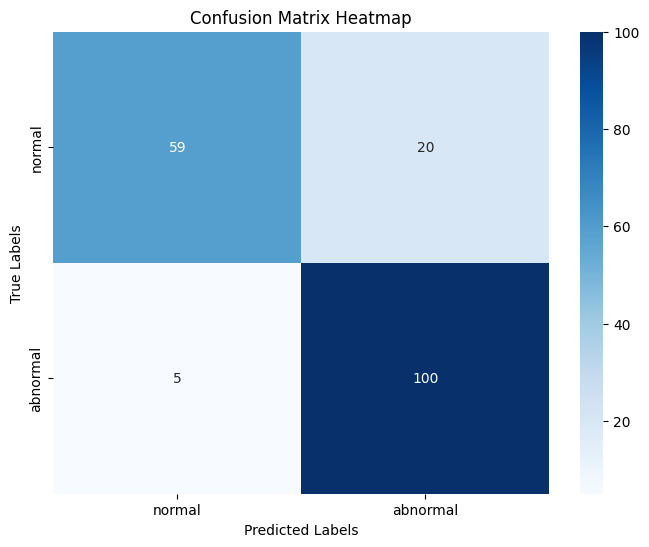

In [228]:
plot_confusion_matrix(y_test, y_test_labels)

In [229]:
def plot_roc_auc_curve(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='lower right')
    plt.show()

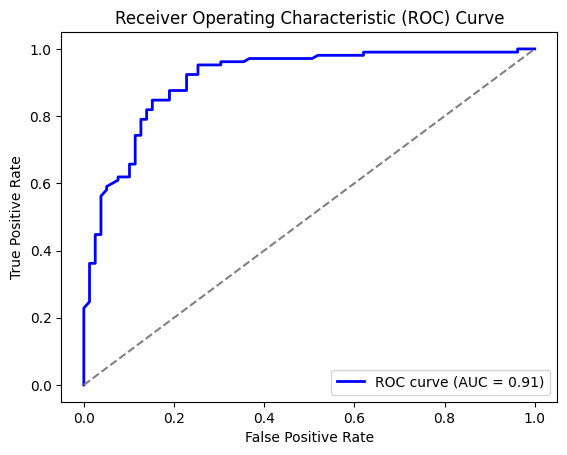

In [232]:
plot_roc_auc_curve(y_test, y_test_probs)